# Part 1 — Randomized Optimization on Final Layers

### Purpose and hypothesis

** Main idea **:Starting from fixed SL SGD-only backbone, can non-gradient search over only the final linear layer improve validation loss or stability enough to justify its evaluation-function and wall-clock cost?

** Hypothesis ** Since gradient-trained solution is already a locally useful basin and the final layer contains only 455 parameters, RHC or SA may make a small validation loss improvement. GA is expected to have heavier tail behavior and higher costs. Any test Macro-F1 gain is expected to be marginal relative to gradient pretraining cost.

Randomized objective is weithed validation cross-entropy on one stratified validation subset. Every objective call counts as one function evaluation. Final selection uses full 4000 row validation split. 561K row test is untouched until all RO choices are locked.


In [41]:
from pathlib import Path
from copy import deepcopy
import os, math, platform, random, time, json, warnings
from dataclasses import dataclass, asdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from IPython.display import display
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, f1_score, precision_recall_fscore_support,
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')

# reproducibility and run modes
BASE_SEED = 42
FULL_SEEDS = [42, 202, 7641]
SMOKE_TEST = os.getenv("OL_SMOKE_TEST", "0") == "1"
QUICK_MODE = os.getenv("OL_QUICK_MODE", "0") == "1" or SMOKE_TEST
SEEDS = [42] if QUICK_MODE else FULL_SEEDS
DEVICE = torch.device(os.getenv("OL_DEVICE", "cpu"))
TORCH_THREADS = max(1, min(4, os.cpu_count() or 1))
torch.set_num_threads(TORCH_THREADS)

def set_all_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True, warn_only=True)

set_all_seeds(BASE_SEED)

# input directories
DATA_PATH = Path("output_data/eda_dataset_original/dataset_stratified.csv")
DATA_PATH_TEST = Path("output_data/eda_dataset_original/dataset_remainder.csv")
RAW_DATA_PATH = Path("dataset_covertype/covtype.data")
TARGET_COL = "Cover_Type"

# Values are fixed by the SL Report notebook.
SL_ARCHITECTURE = (64, 64)
SL_LEARNING_RATE = 0.10
SL_BATCH_SIZE = 512
SL_WEIGHT_DECAY = 1e-4
SL_MAX_EPOCHS = 70
SL_PATIENCE = 10

# Exact SL-notebook reference result from the output.
SL_REFERENCE = {
    "method": "SL PyTorch SGD-only reference",
    "architecture": str(SL_ARCHITECTURE),
    "parameter_count": 8135,
    "learning_rate": 0.10,
    "batch_size": 512,
    "weight_decay": 1e-4,
    "best_epoch": 26,
    "epochs_run": 36,
    "test_accuracy": 0.6400986075,
    "test_macro_f1": 0.5526402660,
    "test_balanced_accuracy": 0.7019769460,
    "fit_time_sec_on_original_hardware": 2.675669709,
}

### 1. Data loading: Exact SL report split and processing

In [42]:
df_source = pd.read_csv(DATA_PATH)
df_test_external = pd.read_csv(DATA_PATH_TEST)

assert TARGET_COL in df_source.columns and TARGET_COL in df_test_external.columns
feature_cols = [c for c in df_source.columns if c != TARGET_COL]
assert len(feature_cols) == 54, f"Expected 54 features, found {len(feature_cols)}"
assert list(df_test_external.columns) == list(df_source.columns), "Development/test columns differ."
assert len(df_source) == 20_000, f"Expected 20,000 sampled rows, found {len(df_source)}"
assert len(df_test_external) == 561_012, f"Expected 561,012 remainder rows, found {len(df_test_external)}"
assert df_source.isna().sum().sum() == 0 and df_test_external.isna().sum().sum() == 0

X_source_df = df_source[feature_cols].copy()
y_source_raw = df_source[TARGET_COL].copy()
X_test_df = df_test_external[feature_cols].copy()
y_test_raw = df_test_external[TARGET_COL].copy()

### 2. Reproducing the SL-report notebook stable class mapping

In [43]:
label_encoder = LabelEncoder()
label_encoder.fit(pd.concat([y_source_raw, y_test_raw], ignore_index=True))
class_labels = label_encoder.classes_
classes = np.arange(len(class_labels))
class_names = [f"Cover_Type_{c}" for c in class_labels]

X_train_df, X_val_df, y_train_raw, y_val_raw = train_test_split(
    X_source_df,
    y_source_raw,
    test_size=0.20,
    stratify=y_source_raw,
    random_state=BASE_SEED,
)

y_train = label_encoder.transform(y_train_raw).astype(np.int64)
y_val = label_encoder.transform(y_val_raw).astype(np.int64)
y_test = label_encoder.transform(y_test_raw).astype(np.int64)

### 3. Leakage safety: fittin learned scalling only on 16K rows training split

In [44]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_df).astype(np.float32)
X_val = scaler.transform(X_val_df).astype(np.float32)
X_test = scaler.transform(X_test_df).astype(np.float32)

class_weights_np = compute_class_weight(
    class_weight="balanced", classes=classes, y=y_train
).astype(np.float32)
class_weights_t = torch.tensor(class_weights_np, dtype=torch.float32, device=DEVICE)

X_train_t = torch.tensor(X_train, dtype=torch.float32, device=DEVICE)
y_train_t = torch.tensor(y_train, dtype=torch.long, device=DEVICE)
X_val_t = torch.tensor(X_val, dtype=torch.float32, device=DEVICE)
y_val_t = torch.tensor(y_val, dtype=torch.long, device=DEVICE)
X_test_t = torch.tensor(X_test, dtype=torch.float32, device=DEVICE)
y_test_t = torch.tensor(y_test, dtype=torch.long, device=DEVICE)

steps_per_epoch = math.ceil(len(y_train) / SL_BATCH_SIZE)

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "source": [DATA_PATH.name, DATA_PATH.name, DATA_PATH_TEST.name],
    "rows": [len(y_train), len(y_val), len(y_test)],
    "purpose": ["fit", "selection only", "final locked evaluation only"],
})
display(split_summary)

print({
    "device": str(DEVICE),
    "torch": torch.__version__,
    "python": platform.python_version(),
    "cpu": platform.processor() or platform.machine(),
    "torch_threads": TORCH_THREADS,
    "quick_mode": QUICK_MODE,
    "seeds": SEEDS,
    "steps_per_epoch": steps_per_epoch,
})


,split,source,rows,purpose
0,train,dataset_stratified.csv,16000,fit
1,validation,dataset_stratified.csv,4000,selection only
2,test,dataset_remainder.csv,561012,final locked evaluation only


{'device': 'cpu', 'torch': '2.5.1', 'python': '3.11.15', 'cpu': 'x86_64', 'torch_threads': 4, 'quick_mode': False, 'seeds': [42, 202, 7641], 'steps_per_epoch': 32}


### 4. Fixing PyTorch backbone with permitted dropout regularizaiton

In [45]:
class CompactMLP(nn.Module):
    """The exact 54 -> 64 -> 64 -> 7 SL backbone.

    Dropout modules are inserted only when Part 3/4 explicitly studies regularization;
    all Linear layer dimensions and ReLU placements remain unchanged.
    """
    def __init__(self, input_dim=54, hidden_layers=SL_ARCHITECTURE, output_dim=7, dropout=0.0):
        super().__init__()
        layers = []
        prev = input_dim
        for width in hidden_layers:
            layers.extend([nn.Linear(prev, width), nn.ReLU()])
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = width
        layers.append(nn.Linear(prev, output_dim))
        self.net = nn.Sequential(*layers)
        self.dropout = float(dropout)

    def forward(self, x):
        return self.net(x)


def count_parameters(model, trainable_only=True):
    params = (p for p in model.parameters() if (p.requires_grad or not trainable_only))
    return sum(p.numel() for p in params)


_base_model_check = CompactMLP().to(DEVICE)
assert count_parameters(_base_model_check) == 8135
print(f"Backbone parameter count confirmed: {count_parameters(_base_model_check):,}")
del _base_model_check

Backbone parameter count confirmed: 8,135


### 5. Metrics and Evaluation

In [46]:
def metric_dict(y_true, y_pred):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
    }


def make_criterion(label_smoothing=0.0):
    return nn.CrossEntropyLoss(weight=class_weights_t, label_smoothing=float(label_smoothing))


def evaluate_tensor(model, X_t, y_t, criterion):
    model.eval()
    with torch.inference_mode():
        logits = model(X_t)
        loss = float(criterion(logits, y_t).item())
        pred = logits.argmax(dim=1).cpu().numpy()
    out = metric_dict(y_t.cpu().numpy(), pred)
    out["loss"] = loss
    return out, pred


def full_report(y_true, y_pred):
    report = pd.DataFrame(classification_report(
        y_true, y_pred, labels=classes, target_names=class_names,
        output_dict=True, zero_division=0,
    )).T
    cm = pd.DataFrame(
        confusion_matrix(y_true, y_pred, labels=classes),
        index=class_names, columns=class_names,
    )
    return report, cm


def clone_state(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


def load_state(model, state):
    model.load_state_dict({k: v.to(DEVICE) for k, v in state.items()})

### 6. Adam without bias correction

In [47]:
class AdamNoBiasCorrection(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8):
        if lr <= 0:
            raise ValueError("lr must be positive")
        defaults = dict(lr=lr, betas=betas, eps=eps)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None if closure is None else closure()
        for group in self.param_groups:
            beta1, beta2 = group["betas"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                g = p.grad
                if g.is_sparse:
                    raise RuntimeError("Sparse gradients are not supported.")
                state = self.state[p]
                if not state:
                    state["step"] = 0
                    state["exp_avg"] = torch.zeros_like(p)
                    state["exp_avg_sq"] = torch.zeros_like(p)
                state["step"] += 1
                m, v = state["exp_avg"], state["exp_avg_sq"]
                m.mul_(beta1).add_(g, alpha=1 - beta1)
                v.mul_(beta2).addcmul_(g, g, value=1 - beta2)
                p.addcdiv_(m, v.sqrt().add_(group["eps"]), value=-group["lr"])
        return loss


def build_optimizer(name, model, lr, beta1=0.9, beta2=0.999, weight_decay=0.0):
    params = [p for p in model.parameters() if p.requires_grad]
    if name == "sgd":
        return torch.optim.SGD(params, lr=lr, momentum=0.0, weight_decay=weight_decay)
    if name == "sgd_momentum":
        return torch.optim.SGD(params, lr=lr, momentum=0.9, nesterov=False, weight_decay=weight_decay)
    if name == "sgd_nesterov":
        return torch.optim.SGD(params, lr=lr, momentum=0.9, nesterov=True, weight_decay=weight_decay)
    if name == "adam":
        return torch.optim.Adam(params, lr=lr, betas=(beta1, beta2), weight_decay=weight_decay)
    if name == "adam_no_bias_correction":
        return AdamNoBiasCorrection(params, lr=lr, betas=(beta1, beta2))
    if name == "adam_beta1_zero":
        return torch.optim.Adam(params, lr=lr, betas=(0.0, beta2), weight_decay=weight_decay)
    if name == "adamw":
        return torch.optim.AdamW(params, lr=lr, betas=(beta1, beta2), weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer: {name}")

### 7. Controlled-budget trainer

In [48]:
@dataclass
class TrainConfig:
    optimizer_name: str
    lr: float
    max_updates: int
    batch_size: int = SL_BATCH_SIZE
    beta1: float = 0.9
    beta2: float = 0.999
    weight_decay: float = 0.0
    dropout: float = 0.0
    label_smoothing: float = 0.0
    input_noise_std: float = 0.0
    early_stopping_patience: int | None = None
    selection_metric: str = "val_loss"
    restore_best: bool = True
    eval_every_updates: int = steps_per_epoch


def train_controlled(config: TrainConfig, seed: int, initial_state=None):
    set_all_seeds(seed)
    model = CompactMLP(dropout=config.dropout).to(DEVICE)
    if initial_state is not None:
        load_state(model, initial_state)
    criterion = make_criterion(config.label_smoothing)
    optimizer = build_optimizer(
        config.optimizer_name, model, config.lr, config.beta1, config.beta2, config.weight_decay
    )

    n = len(y_train)
    update = 0
    history = []
    start_time = time.perf_counter()
    best_score = np.inf if config.selection_metric == "val_loss" else -np.inf
    best_state = clone_state(model)
    best_update = 0
    stale_evals = 0
    stopped_early = False
    interval_loss_sum = 0.0
    interval_examples = 0

    while update < config.max_updates:
        model.train()
        permutation = torch.randperm(n, device=DEVICE)
        for batch_start in range(0, n, config.batch_size):
            if update >= config.max_updates:
                break
            idx = permutation[batch_start: batch_start + config.batch_size]
            xb = X_train_t[idx]
            if config.input_noise_std > 0:
                xb = xb + torch.randn_like(xb) * config.input_noise_std
            yb = y_train_t[idx]

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            update += 1
            interval_loss_sum += float(loss.item()) * len(idx)
            interval_examples += len(idx)

            should_eval = (
                update == 1
                or update % config.eval_every_updates == 0
                or update == config.max_updates
            )
            if not should_eval:
                continue

            train_metrics, _ = evaluate_tensor(model, X_train_t, y_train_t, criterion)
            val_metrics, _ = evaluate_tensor(model, X_val_t, y_val_t, criterion)
            elapsed = time.perf_counter() - start_time
            row = {
                "seed": seed,
                "update": update,
                "gradient_evaluations": update,
                "optimizer_updates": update,
                "examples_seen": update * config.batch_size,
                "wall_time_sec": elapsed,
                "interval_train_loss": interval_loss_sum / max(1, interval_examples),
                **{f"train_{k}": v for k, v in train_metrics.items()},
                **{f"val_{k}": v for k, v in val_metrics.items()},
            }
            history.append(row)
            interval_loss_sum = 0.0
            interval_examples = 0

            score = val_metrics[config.selection_metric.replace("val_", "")]
            improved = score < best_score - 1e-6 if config.selection_metric == "val_loss" else score > best_score + 1e-6
            if improved:
                best_score = score
                best_state = clone_state(model)
                best_update = update
                stale_evals = 0
            else:
                stale_evals += 1

            if config.early_stopping_patience is not None and stale_evals >= config.early_stopping_patience:
                stopped_early = True
                break
        if stopped_early:
            break

    total_time = time.perf_counter() - start_time
    final_state = clone_state(model)
    if config.restore_best:
        load_state(model, best_state)
    selected_metrics, selected_pred = evaluate_tensor(model, X_val_t, y_val_t, criterion)

    return {
        "model": model,
        "config": asdict(config),
        "seed": seed,
        "history": pd.DataFrame(history),
        "best_state": best_state,
        "final_state": final_state,
        "best_update": int(best_update),
        "updates_run": int(update),
        "gradient_evaluations": int(update),
        "wall_time_sec": float(total_time),
        "stopped_early": stopped_early,
        "selected_val_metrics": selected_metrics,
        "selected_val_pred": selected_pred,
        "parameter_count": count_parameters(model),
    }


def evaluate_test_locked(run, method_name):
    """Call only after all validation-based choices have been locked."""
    criterion = make_criterion(run["config"].get("label_smoothing", 0.0))
    metrics, pred = evaluate_tensor(run["model"], X_test_t, y_test_t, criterion)
    report, cm = full_report(y_test, pred)
    row = {
        "method": method_name,
        "seed": run["seed"],
        "best_val_loss": run["selected_val_metrics"]["loss"],
        "best_val_macro_f1": run["selected_val_metrics"]["macro_f1"],
        "test_accuracy": metrics["accuracy"],
        "test_macro_f1": metrics["macro_f1"],
        "test_balanced_accuracy": metrics["balanced_accuracy"],
        "wall_time_sec": run["wall_time_sec"],
        "gradient_evaluations": run["gradient_evaluations"],
        "function_evaluations": 0,
        "notes": json.dumps(run["config"], sort_keys=True),
    }
    return row, report, cm, pred


def representative_seed(summary_df, metric="best_val_macro_f1"):
    med = summary_df[metric].median()
    idx = (summary_df[metric] - med).abs().idxmin()
    return int(summary_df.loc[idx, "seed"])


def save_json(path, obj):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, sort_keys=True)


def plot_confusion_matrix(cm_df, title, path):
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm_df.values, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_xticks(range(len(class_labels)), class_labels)
    ax.set_yticks(range(len(class_labels)), class_labels)
    fig.colorbar(im, ax=ax)
    threshold = cm_df.values.max() * 0.55
    for i in range(cm_df.shape[0]):
        for j in range(cm_df.shape[1]):
            ax.text(j, i, str(cm_df.iat[i, j]), ha="center", va="center",
                    fontsize=7, color="white" if cm_df.iat[i, j] > threshold else "black")
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()

### 8. Control audit

In [49]:
VERIFY_RAW_MULTISET = not QUICK_MODE
raw_shape = pd.read_csv(RAW_DATA_PATH, header=None, nrows=5).shape
assert raw_shape[1] == 55

class_balance = pd.concat([
    y_source_raw.value_counts().sort_index().rename("sampled_20k"),
    y_test_raw.value_counts().sort_index().rename("remainder_test"),
], axis=1)
class_balance["combined"] = class_balance.sum(axis=1)
class_balance["sample_percent"] = 100 * class_balance["sampled_20k"] / class_balance["combined"]
display(class_balance)

if VERIFY_RAW_MULTISET:
    raw = pd.read_csv(RAW_DATA_PATH, header=None)
    raw.columns = df_source.columns
    combined = pd.concat([df_source, df_test_external], ignore_index=True)
    raw_hashes = pd.util.hash_pandas_object(raw, index=False).value_counts().sort_index()
    combined_hashes = pd.util.hash_pandas_object(combined, index=False).value_counts().sort_index()
    assert raw_hashes.equals(combined_hashes), "Prepared sample + remainder do not reconstruct covtype.data."
    print("Exact row-multiset verification passed: sample + remainder == covtype.data.")
else:
    print("Quick/smoke mode: skipped the full 581,012-row multiset hash check.")

,sampled_20k,remainder_test,combined,sample_percent
Cover_Type,,,,
1,7292,204548,211840,3.442221
2,9752,273549,283301,3.442275
3,1231,34523,35754,3.442971
4,94,2653,2747,3.421915
5,327,9166,9493,3.444643
6,598,16769,17367,3.443312
7,706,19804,20510,3.442223


Exact row-multiset verification passed: sample + remainder == covtype.data.


### 9. Randomized optimization helpers

In [50]:
def get_linear_modules(model):
    return [m for m in model.modules() if isinstance(m, nn.Linear)]


def freeze_for_ro(model, final_linear_layers=1):
    for p in model.parameters():
        p.requires_grad = False
    linear_layers = get_linear_modules(model)
    selected = linear_layers[-final_linear_layers:]
    for layer in selected:
        for p in layer.parameters():
            p.requires_grad = True
    trainable = [p for p in model.parameters() if p.requires_grad]
    trainable_count = sum(p.numel() for p in trainable)
    if trainable_count > 50_000:
        raise ValueError(f"RO trainable parameter count {trainable_count:,} exceeds 50,000.")
    return trainable, trainable_count


def vector_from_params(params):
    return torch.cat([p.detach().flatten().cpu() for p in params]).numpy().astype(np.float32)


def vector_to_params(vector, params):
    vector_t = torch.tensor(vector, dtype=torch.float32, device=DEVICE)
    offset = 0
    with torch.no_grad():
        for p in params:
            n = p.numel()
            p.copy_(vector_t[offset:offset+n].view_as(p))
            offset += n
    assert offset == len(vector)


def make_fixed_ro_validation_subset(size=2000, seed=BASE_SEED):
    size = min(size, len(y_val))
    idx, _ = train_test_split(
        np.arange(len(y_val)), train_size=size, stratify=y_val, random_state=seed
    )
    idx_t = torch.tensor(np.sort(idx), dtype=torch.long, device=DEVICE)
    return X_val_t[idx_t], y_val_t[idx_t], idx


RO_X_t, RO_y_t, RO_indices = make_fixed_ro_validation_subset(1000 if QUICK_MODE else 2000)


def make_ro_objective(model, params, criterion):
    calls = {"count": 0}
    def objective(vector):
        vector_to_params(vector, params)
        model.eval()
        with torch.inference_mode():
            value = float(criterion(model(RO_X_t), RO_y_t).item())
        calls["count"] += 1
        return value
    return objective, calls


def rhc_optimize(objective, x0, budget, seed, restart_patience=50,
                 initial_step=0.025, step_decay=0.995, min_step=0.002,
                 restart_scale=0.05):
    rng = np.random.default_rng(seed)
    start = time.perf_counter()
    current = x0.copy()
    current_obj = objective(current)
    best, best_obj = current.copy(), current_obj
    history = [{"function_evaluation": 1, "current_objective": current_obj,
                "best_objective": best_obj, "wall_time_sec": time.perf_counter()-start,
                "accepted": True, "restart": False}]
    no_improve = 0
    restarts = 0
    while len(history) < budget:
        fe = len(history) + 1
        step = max(min_step, initial_step * (step_decay ** (fe - 1)))
        is_restart = no_improve >= restart_patience
        if is_restart:
            candidate = x0 + rng.normal(0, restart_scale, size=x0.shape).astype(np.float32)
            restarts += 1
            no_improve = 0
        else:
            candidate = current + rng.normal(0, step, size=x0.shape).astype(np.float32)
        candidate_obj = objective(candidate)
        accepted = is_restart or candidate_obj < current_obj
        if accepted:
            current, current_obj = candidate, candidate_obj
        if candidate_obj < best_obj:
            best, best_obj = candidate.copy(), candidate_obj
            no_improve = 0
        else:
            no_improve += 1
        history.append({"function_evaluation": fe, "current_objective": current_obj,
                        "best_objective": best_obj, "wall_time_sec": time.perf_counter()-start,
                        "accepted": accepted, "restart": is_restart, "step_scale": step})
    return best, best_obj, pd.DataFrame(history), {"restarts": restarts}


def sa_optimize(objective, x0, budget, seed, initial_temperature=0.10,
                decay=0.985, initial_step=0.025, min_step=0.0015):
    rng = np.random.default_rng(seed)
    start = time.perf_counter()
    current = x0.copy()
    current_obj = objective(current)
    best, best_obj = current.copy(), current_obj
    history = [{"function_evaluation": 1, "current_objective": current_obj,
                "best_objective": best_obj, "wall_time_sec": time.perf_counter()-start,
                "accepted": True, "temperature": initial_temperature,
                "step_scale": initial_step}]
    accepted_count = 1
    while len(history) < budget:
        fe = len(history) + 1
        temperature = initial_temperature * (decay ** (fe - 1))
        step = max(min_step, initial_step * math.sqrt(max(temperature, 1e-12) / initial_temperature))
        candidate = current + rng.normal(0, step, size=x0.shape).astype(np.float32)
        candidate_obj = objective(candidate)
        delta = candidate_obj - current_obj
        accept = delta <= 0 or rng.random() < math.exp(-delta / max(temperature, 1e-12))
        if accept:
            current, current_obj = candidate, candidate_obj
            accepted_count += 1
        if candidate_obj < best_obj:
            best, best_obj = candidate.copy(), candidate_obj
        history.append({"function_evaluation": fe, "current_objective": current_obj,
                        "best_objective": best_obj, "wall_time_sec": time.perf_counter()-start,
                        "accepted": accept, "temperature": temperature, "step_scale": step})
    return best, best_obj, pd.DataFrame(history), {"acceptance_rate": accepted_count / budget}


def ga_optimize(objective, x0, budget, seed, population_size=20,
                tournament_size=3, crossover_blend=0.25, mutation_rate=0.05,
                mutation_scale=0.02, elite_count=2):
    rng = np.random.default_rng(seed)
    population_size = min(population_size, budget)
    elite_count = min(elite_count, population_size - 1)
    start = time.perf_counter()
    population = [x0.copy()]
    population += [x0 + rng.normal(0, 0.04, size=x0.shape).astype(np.float32)
                   for _ in range(population_size - 1)]
    scores, history = [], []
    best, best_obj = x0.copy(), np.inf
    fe = 0
    for individual in population:
        if fe >= budget:
            break
        score = objective(individual); fe += 1; scores.append(score)
        if score < best_obj:
            best, best_obj = individual.copy(), score
        history.append({"function_evaluation": fe, "current_objective": score,
                        "best_objective": best_obj, "wall_time_sec": time.perf_counter()-start,
                        "generation": 0})
    population = population[:len(scores)]
    scores = np.asarray(scores)
    generation = 0

    def tournament_pick():
        ids = rng.integers(0, len(population), size=min(tournament_size, len(population)))
        return population[int(ids[np.argmin(scores[ids])])]

    while fe < budget:
        generation += 1
        order = np.argsort(scores)
        next_population = [population[i].copy() for i in order[:elite_count]]
        next_scores = [float(scores[i]) for i in order[:elite_count]]
        while len(next_population) < population_size and fe < budget:
            p1, p2 = tournament_pick(), tournament_pick()
            alpha = rng.uniform(-crossover_blend, 1 + crossover_blend, size=x0.shape).astype(np.float32)
            child = alpha * p1 + (1 - alpha) * p2
            mask = rng.random(x0.shape) < mutation_rate
            if mask.any():
                child[mask] += rng.normal(0, mutation_scale, size=int(mask.sum())).astype(np.float32)
            score = objective(child); fe += 1
            next_population.append(child.astype(np.float32)); next_scores.append(score)
            if score < best_obj:
                best, best_obj = child.copy(), score
            history.append({"function_evaluation": fe, "current_objective": score,
                            "best_objective": best_obj, "wall_time_sec": time.perf_counter()-start,
                            "generation": generation})
        population, scores = next_population, np.asarray(next_scores)
    return best, best_obj, pd.DataFrame(history), {"generations": generation}


def run_ro_algorithm(name, objective, x0, budget, seed, settings=None):
    settings = dict(settings or {})
    if name == "RHC":
        return rhc_optimize(objective, x0, budget, seed, **settings)
    if name == "SA":
        return sa_optimize(objective, x0, budget, seed, **settings)
    if name == "GA":
        return ga_optimize(objective, x0, budget, seed, **settings)
    raise ValueError(name)

### 10. RO configuraton and conpute budget

In [51]:
PART = "ol_part1"
FIG_DIR = Path("output_figures") / PART
RESULTS_DIR = Path("output_results") / PART
FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

FINAL_LINEAR_LAYERS = 1
RO_BUDGET = 40 if QUICK_MODE else 300
PRETRAIN_MAX_UPDATES = 160 if QUICK_MODE else SL_MAX_EPOCHS * steps_per_epoch

RO_SETTINGS = {
    "RHC": {
        "restart_patience": 50,
        "initial_step": 0.025,
        "step_decay": 0.995,
        "min_step": 0.002,
        "restart_scale": 0.05,
    },
    "SA": {
        "initial_temperature": 0.10,
        "decay": 0.985,
        "initial_step": 0.025,
        "min_step": 0.0015,
    },
    "GA": {
        "population_size": 8 if QUICK_MODE else 20,
        "tournament_size": 3,
        "crossover_blend": 0.25,
        "mutation_rate": 0.05,
        "mutation_scale": 0.02,
        "elite_count": 2,
    },
}

budget_table = pd.DataFrame([
    {"component": "SL-style SGD pretraining", "budget_type": "gradient evaluations / updates",
     "budget": PRETRAIN_MAX_UPDATES, "notes": "max cap; early stopping on validation Macro-F1"},
    *[{"component": name, "budget_type": "validation objective calls / function evaluations",
       "budget": RO_BUDGET, "notes": json.dumps(settings)} for name, settings in RO_SETTINGS.items()],
])
display(budget_table)
save_json(RESULTS_DIR / "ro_settings.json", {
    "final_linear_layers": FINAL_LINEAR_LAYERS,
    "ro_function_evaluation_budget": RO_BUDGET,
    "validation_subset_rows": int(len(RO_y_t)),
    "settings": RO_SETTINGS,
})

,component,budget_type,budget,notes
0,SL-style SGD pretraining,gradient evaluations / updates,2240,max cap; early stopping on validation Macro-F1
1,RHC,validation objective calls / function evaluations,300,"{""restart_patience"": 50, ""initial_step"": 0.025..."
2,SA,validation objective calls / function evaluations,300,"{""initial_temperature"": 0.1, ""decay"": 0.985, ""..."
3,GA,validation objective calls / function evaluations,300,"{""population_size"": 20, ""tournament_size"": 3, ..."


### 11. Reproducgin SL PyTorch baseline for each seed

In [52]:
pretrain_config = TrainConfig(
    optimizer_name="sgd",
    lr=SL_LEARNING_RATE,
    max_updates=PRETRAIN_MAX_UPDATES,
    batch_size=SL_BATCH_SIZE,
    weight_decay=SL_WEIGHT_DECAY,
    early_stopping_patience=2 if QUICK_MODE else SL_PATIENCE,
    selection_metric="val_macro_f1",
    restore_best=True,
)

pretrained_runs = {}
pretrain_rows = []
for seed in SEEDS:
    run = train_controlled(pretrain_config, seed)
    pretrained_runs[seed] = run
    pretrain_rows.append({
        "method": "SL SGD pretraining",
        "seed": seed,
        "val_loss": run["selected_val_metrics"]["loss"],
        "val_macro_f1": run["selected_val_metrics"]["macro_f1"],
        "val_balanced_accuracy": run["selected_val_metrics"]["balanced_accuracy"],
        "gradient_evaluations": run["gradient_evaluations"],
        "wall_time_sec": run["wall_time_sec"],
        "best_update": run["best_update"],
    })
pretrain_summary = pd.DataFrame(pretrain_rows)
pretrain_summary.to_csv(RESULTS_DIR / "pretrain_seed_summary.csv", index=False)
display(pretrain_summary)

,method,seed,val_loss,val_macro_f1,val_balanced_accuracy,gradient_evaluations,wall_time_sec,best_update
0,SL SGD pretraining,42,0.700434,0.554536,0.706070,1152,1.620030,832
1,SL SGD pretraining,202,0.720262,0.554109,0.712362,1440,1.852517,1120
2,SL SGD pretraining,7641,0.762781,0.524839,0.700967,800,1.225034,480


### 12. RHC, SA, and GA under identical function-evaluation budgets

In [53]:
ro_runs = {}
ro_summary_rows = []
progress_frames = []

for seed, pretrained in pretrained_runs.items():
    for algorithm in ["RHC", "SA", "GA"]:
        model = CompactMLP().to(DEVICE)
        load_state(model, pretrained["best_state"])
        params, trainable_count = freeze_for_ro(model, FINAL_LINEAR_LAYERS)
        assert trainable_count <= 50_000
        x0 = vector_from_params(params)
        criterion = make_criterion(label_smoothing=0.0)
        objective, call_counter = make_ro_objective(model, params, criterion)

        best_x, subset_best_loss, history, diagnostics = run_ro_algorithm(
            algorithm, objective, x0, RO_BUDGET, seed, RO_SETTINGS[algorithm]
        )
        assert call_counter["count"] == RO_BUDGET
        vector_to_params(best_x, params)
        full_val_metrics, full_val_pred = evaluate_tensor(model, X_val_t, y_val_t, criterion)
        state = clone_state(model)
        total_ro_time = float(history["wall_time_sec"].iloc[-1])

        key = (algorithm, seed)
        ro_runs[key] = {
            "model": model,
            "state": state,
            "seed": seed,
            "algorithm": algorithm,
            "history": history,
            "trainable_parameter_count": trainable_count,
            "subset_best_loss": subset_best_loss,
            "full_val_metrics": full_val_metrics,
            "function_evaluations": RO_BUDGET,
            "ro_wall_time_sec": total_ro_time,
            "pretrain_gradient_evaluations": pretrained["gradient_evaluations"],
            "pretrain_wall_time_sec": pretrained["wall_time_sec"],
            "diagnostics": diagnostics,
        }
        history = history.copy()
        history["algorithm"] = algorithm
        history["seed"] = seed
        progress_frames.append(history)
        ro_summary_rows.append({
            "algorithm": algorithm,
            "seed": seed,
            "trainable_parameter_count": trainable_count,
            "subset_best_val_loss": subset_best_loss,
            "full_val_loss": full_val_metrics["loss"],
            "full_val_macro_f1": full_val_metrics["macro_f1"],
            "full_val_balanced_accuracy": full_val_metrics["balanced_accuracy"],
            "function_evaluations": RO_BUDGET,
            "ro_wall_time_sec": total_ro_time,
            "pretrain_gradient_evaluations": pretrained["gradient_evaluations"],
            "pretrain_wall_time_sec": pretrained["wall_time_sec"],
            **diagnostics,
        })

ro_progress = pd.concat(progress_frames, ignore_index=True)
ro_summary = pd.DataFrame(ro_summary_rows)
ro_progress.to_csv(RESULTS_DIR / "ro_progress.csv", index=False)
ro_summary.to_csv(RESULTS_DIR / "ro_validation_summary.csv", index=False)
display(ro_summary)
print(f"Exact RO trainable parameter count: {int(ro_summary.trainable_parameter_count.iloc[0]):,}")

,algorithm,seed,trainable_parameter_count,subset_best_val_loss,full_val_loss,full_val_macro_f1,full_val_balanced_accuracy,function_evaluations,ro_wall_time_sec,pretrain_gradient_evaluations,pretrain_wall_time_sec,restarts,acceptance_rate,generations
0,RHC,42,455,0.613110,0.650535,0.535499,0.731924,300,0.289183,1152,1.620030,0.0,NaN,NaN
1,SA,42,455,0.700258,0.691495,0.551797,0.720375,300,0.310590,1152,1.620030,NaN,0.810000,NaN
2,GA,42,455,0.653427,0.655523,0.521386,0.721410,300,0.382407,1152,1.620030,NaN,NaN,16.0
3,RHC,202,455,0.598858,0.634385,0.534182,0.737583,300,0.303786,1440,1.852517,0.0,NaN,NaN
4,SA,202,455,0.708395,0.710218,0.544265,0.717735,300,0.303474,1440,1.852517,NaN,0.843333,NaN
5,GA,202,455,0.642984,0.652022,0.514854,0.722498,300,0.378530,1440,1.852517,NaN,NaN,16.0
6,RHC,7641,455,0.698103,0.725421,0.509533,0.717708,300,0.287504,800,1.225034,0.0,NaN,NaN
7,SA,7641,455,0.769887,0.762934,0.515408,0.690531,300,0.286440,800,1.225034,NaN,0.833333,NaN
8,GA,7641,455,0.729585,0.734448,0.509391,0.709315,300,0.317988,800,1.225034,NaN,NaN,16.0


Exact RO trainable parameter count: 455


### 13. Required RO progress and compute figures

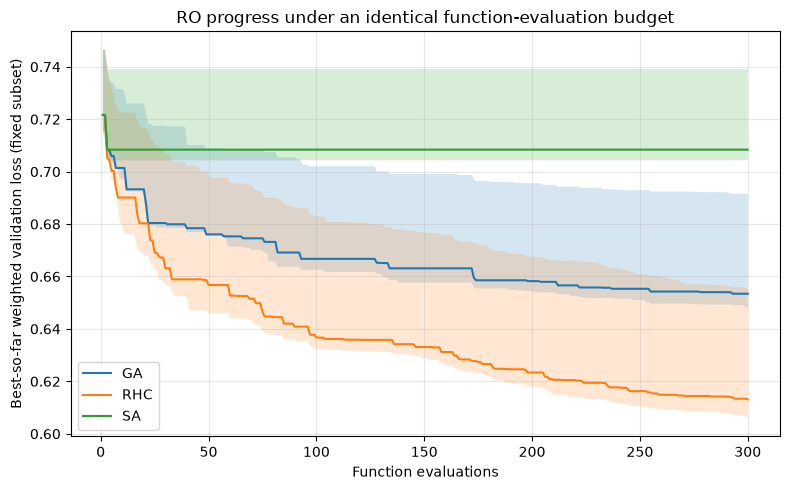

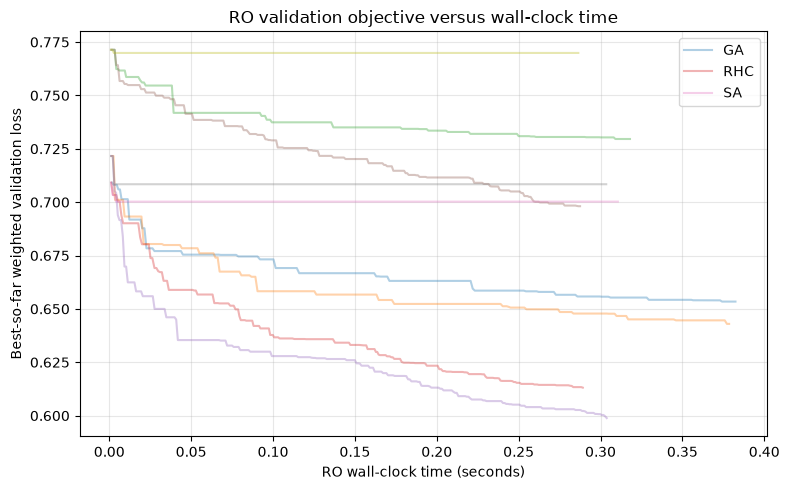

,algorithm,median_val_loss,iqr_val_loss,median_val_macro_f1,std_val_macro_f1,median_ro_time_sec
0,GA,0.655523,0.041213,0.514854,0.006006,0.378530
1,RHC,0.650535,0.045518,0.534182,0.014626,0.289183
2,SA,0.710218,0.035719,0.544265,0.019208,0.303474


In [54]:
plt.figure(figsize=(8, 5))
for algorithm, group in ro_progress.groupby("algorithm"):
    pivot = group.pivot_table(index="function_evaluation", columns="seed", values="best_objective")
    med = pivot.median(axis=1)
    q1, q3 = pivot.quantile(0.25, axis=1), pivot.quantile(0.75, axis=1)
    plt.plot(med.index, med.values, label=algorithm)
    if len(pivot.columns) > 1:
        plt.fill_between(med.index, q1.values, q3.values, alpha=0.18)
plt.xlabel("Function evaluations")
plt.ylabel("Best-so-far weighted validation loss (fixed subset)")
plt.title("RO progress under an identical function-evaluation budget")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
plt.savefig(FIG_DIR / "ro_best_objective_vs_function_evaluations.png", dpi=160, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
for algorithm, group in ro_progress.groupby("algorithm"):
    for seed, run_group in group.groupby("seed"):
        plt.plot(run_group["wall_time_sec"], run_group["best_objective"],
                 alpha=0.35, label=algorithm if seed == SEEDS[0] else None)
plt.xlabel("RO wall-clock time (seconds)")
plt.ylabel("Best-so-far weighted validation loss")
plt.title("RO validation objective versus wall-clock time")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
plt.savefig(FIG_DIR / "ro_validation_loss_vs_wall_time.png", dpi=160, bbox_inches="tight")
plt.show()

stability = ro_summary.groupby("algorithm").agg(
    median_val_loss=("full_val_loss", "median"),
    iqr_val_loss=("full_val_loss", lambda x: x.quantile(.75)-x.quantile(.25)),
    median_val_macro_f1=("full_val_macro_f1", "median"),
    std_val_macro_f1=("full_val_macro_f1", "std"),
    median_ro_time_sec=("ro_wall_time_sec", "median"),
).reset_index()
stability.to_csv(RESULTS_DIR / "ro_stability_summary.csv", index=False)
display(stability)

### 14. Lock algorithm by validation only

In [55]:
algorithm_ranking = ro_summary.groupby("algorithm").agg(
    median_full_val_loss=("full_val_loss", "median"),
    median_full_val_macro_f1=("full_val_macro_f1", "median"),
    median_ro_time_sec=("ro_wall_time_sec", "median"),
).reset_index().sort_values(["median_full_val_loss", "median_full_val_macro_f1"], ascending=[True, False])
best_ro_algorithm = algorithm_ranking.iloc[0]["algorithm"]
display(algorithm_ranking)
print("Locked best RO algorithm:", best_ro_algorithm)

best_ro_config = {
    "algorithm": best_ro_algorithm,
    "settings": RO_SETTINGS[best_ro_algorithm],
    "part1_function_evaluation_budget": RO_BUDGET,
    "final_linear_layers": FINAL_LINEAR_LAYERS,
    "trainable_parameter_count": int(ro_summary.trainable_parameter_count.iloc[0]),
    "validation_subset_rows": int(len(RO_y_t)),
    "selection_rule": "lowest median full-validation loss; Macro-F1 tie-break",
}
save_json(RESULTS_DIR / "best_ro_config.json", best_ro_config)

final_rows, reports, cms = [], {}, {}

,algorithm,median_full_val_loss,median_full_val_macro_f1,median_ro_time_sec
1,RHC,0.650535,0.534182,0.289183
0,GA,0.655523,0.514854,0.378530
2,SA,0.710218,0.544265,0.303474


Locked best RO algorithm: RHC


### 15. Performing final test evaluation

,method,seed,best_val_loss,best_val_macro_f1,test_accuracy,test_macro_f1,test_balanced_accuracy,wall_time_sec,gradient_evaluations,function_evaluations,notes
0,SL SGD pretraining,42,0.700434,0.554536,0.640099,0.552640,0.701977,1.620030,1152,0,"{""batch_size"": 512, ""beta1"": 0.9, ""beta2"": 0.9..."
1,SL SGD + RHC final-layer RO,42,0.650535,0.535499,0.630286,0.532151,0.719031,1.909212,1152,300,RO trainable params=455
2,SL SGD + SA final-layer RO,42,0.691495,0.551797,0.627963,0.546828,0.704102,1.930620,1152,300,RO trainable params=455
3,SL SGD + GA final-layer RO,42,0.655523,0.521386,0.610140,0.524480,0.720811,2.002437,1152,300,RO trainable params=455
4,SL SGD pretraining,202,0.720262,0.554109,0.665938,0.542422,0.693139,1.852517,1440,0,"{""batch_size"": 512, ""beta1"": 0.9, ""beta2"": 0.9..."
5,SL SGD + RHC final-layer RO,202,0.634385,0.534182,0.624263,0.521892,0.721780,2.156303,1440,300,RO trainable params=455
6,SL SGD + SA final-layer RO,202,0.710218,0.544265,0.656437,0.532903,0.697954,2.155991,1440,300,RO trainable params=455
7,SL SGD + GA final-layer RO,202,0.652022,0.514854,0.630880,0.520975,0.723309,2.231047,1440,300,RO trainable params=455
8,SL SGD pretraining,7641,0.762781,0.524839,0.621425,0.522858,0.691996,1.225034,800,0,"{""batch_size"": 512, ""beta1"": 0.9, ""beta2"": 0.9..."
9,SL SGD + RHC final-layer RO,7641,0.725421,0.509533,0.613502,0.501850,0.690801,1.512538,800,300,RO trainable params=455


,precision,recall,f1-score,support
Cover_Type_1,0.684136,0.676169,0.680129,204548.000000
Cover_Type_2,0.800427,0.557834,0.657466,273549.000000
Cover_Type_3,0.642816,0.607624,0.624725,34523.000000
Cover_Type_4,0.286645,0.846212,0.428231,2653.000000
Cover_Type_5,0.138639,0.822605,0.237286,9166.000000
Cover_Type_6,0.360020,0.654064,0.464411,16769.000000
Cover_Type_7,0.410021,0.887952,0.560997,19804.000000
accuracy,0.624263,0.624263,0.624263,0.624263
macro avg,0.474672,0.721780,0.521892,561012.000000
weighted avg,0.708140,0.624263,0.646589,561012.000000


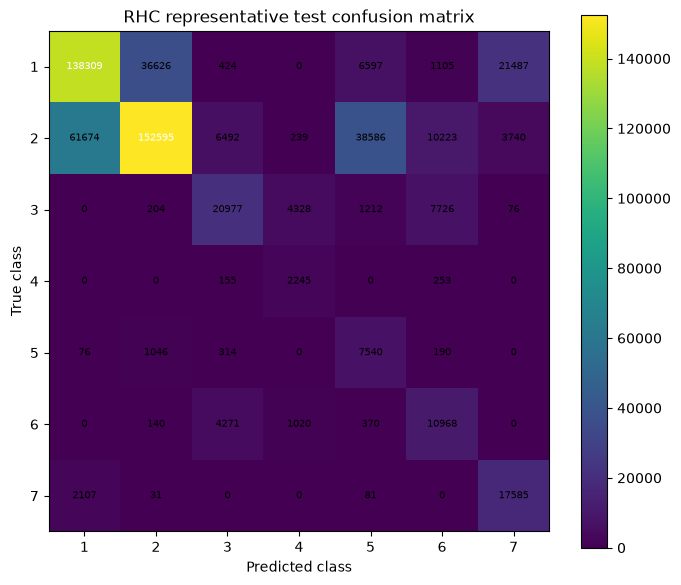

In [56]:
if not SMOKE_TEST:
    for seed, pre in pretrained_runs.items():
        base_row, base_report, base_cm, _ = evaluate_test_locked(pre, "SL SGD pretraining")
        final_rows.append(base_row); reports[("SL SGD pretraining", seed)] = base_report; cms[("SL SGD pretraining", seed)] = base_cm
        for algorithm in ["RHC", "SA", "GA"]:
            rr = ro_runs[(algorithm, seed)]
            criterion = make_criterion()
            test_metrics, pred = evaluate_tensor(rr["model"], X_test_t, y_test_t, criterion)
            report, cm = full_report(y_test, pred)
            final_rows.append({
                "method": f"SL SGD + {algorithm} final-layer RO",
                "seed": seed,
                "best_val_loss": rr["full_val_metrics"]["loss"],
                "best_val_macro_f1": rr["full_val_metrics"]["macro_f1"],
                "test_accuracy": test_metrics["accuracy"],
                "test_macro_f1": test_metrics["macro_f1"],
                "test_balanced_accuracy": test_metrics["balanced_accuracy"],
                "wall_time_sec": rr["pretrain_wall_time_sec"] + rr["ro_wall_time_sec"],
                "gradient_evaluations": rr["pretrain_gradient_evaluations"],
                "function_evaluations": rr["function_evaluations"],
                "notes": f"RO trainable params={rr['trainable_parameter_count']}",
            })
            reports[(algorithm, seed)] = report; cms[(algorithm, seed)] = cm

    final_metric_table = pd.DataFrame(final_rows)
    final_metric_table.to_csv(RESULTS_DIR / "final_metric_table.csv", index=False)
    display(final_metric_table)

    rep_seed = representative_seed(
        final_metric_table[final_metric_table.method.eq(f"SL SGD + {best_ro_algorithm} final-layer RO")]
    )
    reports[(best_ro_algorithm, rep_seed)].to_csv(RESULTS_DIR / "representative_classification_report.csv")
    cms[(best_ro_algorithm, rep_seed)].to_csv(RESULTS_DIR / "representative_confusion_matrix.csv")
    display(reports[(best_ro_algorithm, rep_seed)])
    plot_confusion_matrix(cms[(best_ro_algorithm, rep_seed)],
                          f"{best_ro_algorithm} representative test confusion matrix",
                          FIG_DIR / "best_ro_confusion_matrix.png")
else:
    print("Smoke test mode: final held-out test evaluation intentionally skipped.")